In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
# LOAD MNIST DATASET
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (60000, 28, 28)
Testing Shape : (10000, 28, 28)


In [3]:
# PREPROCESSING

# Normalize pixel values to [0,1]

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# CNN expects:
# (samples, height, width, channels)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("\nNew Training Shape:", X_train.shape)


New Training Shape: (60000, 28, 28, 1)


In [4]:
# CNN MODEL

model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])


# COMPILE
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# MODEL SUMMARY
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [5]:
# TRAIN

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64
)


Epoch 1/5


2026-06-21 19:18:52.529534: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


844/844 [==============================] - 8s 10ms/step - loss: 0.2554 - accuracy: 0.9215 - val_loss: 0.0492 - val_accuracy: 0.9853
Epoch 2/5
844/844 [==============================] - 8s 10ms/step - loss: 0.0876 - accuracy: 0.9741 - val_loss: 0.0396 - val_accuracy: 0.9877
Epoch 3/5
844/844 [==============================] - 8s 10ms/step - loss: 0.0653 - accuracy: 0.9801 - val_loss: 0.0339 - val_accuracy: 0.9912
Epoch 4/5
844/844 [==============================] - 8s 10ms/step - loss: 0.0513 - accuracy: 0.9849 - val_loss: 0.0343 - val_accuracy: 0.9902
Epoch 5/5
844/844 [==============================] - 8s 10ms/step - loss: 0.0441 - accuracy: 0.9866 - val_loss: 0.0356 - val_accuracy: 0.9912


In [6]:
# EVALUATE

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


313/313 [==============================] - 1s 2ms/step - loss: 0.0269 - accuracy: 0.9921

Test Loss: 0.026943771168589592
Test Accuracy: 0.9921000003814697


In [7]:
# PREDICTION

predictions = model.predict(X_test)

predicted_classes = tf.argmax(
    predictions,
    axis=1
)

print("\nFirst 10 Predictions:")
print(predicted_classes[:10].numpy())

print("\nActual Labels:")
print(y_test[:10])


313/313 [==============================] - 1s 2ms/step

First 10 Predictions:
[7 2 1 0 4 1 4 9 5 9]

Actual Labels:
[7 2 1 0 4 1 4 9 5 9]


In [8]:

# SINGLE IMAGE PREDICTION

sample = X_test[0].reshape(1,28,28,1)

prediction = model.predict(sample)

digit = tf.argmax(
    prediction,
    axis=1
)

print("\nPredicted Digit:", digit.numpy()[0])
print("Actual Digit   :", y_test[0])

1/1 [==============================] - 0s 18ms/step

Predicted Digit: 7
Actual Digit   : 7


313/313 [==============================] - 1s 2ms/step


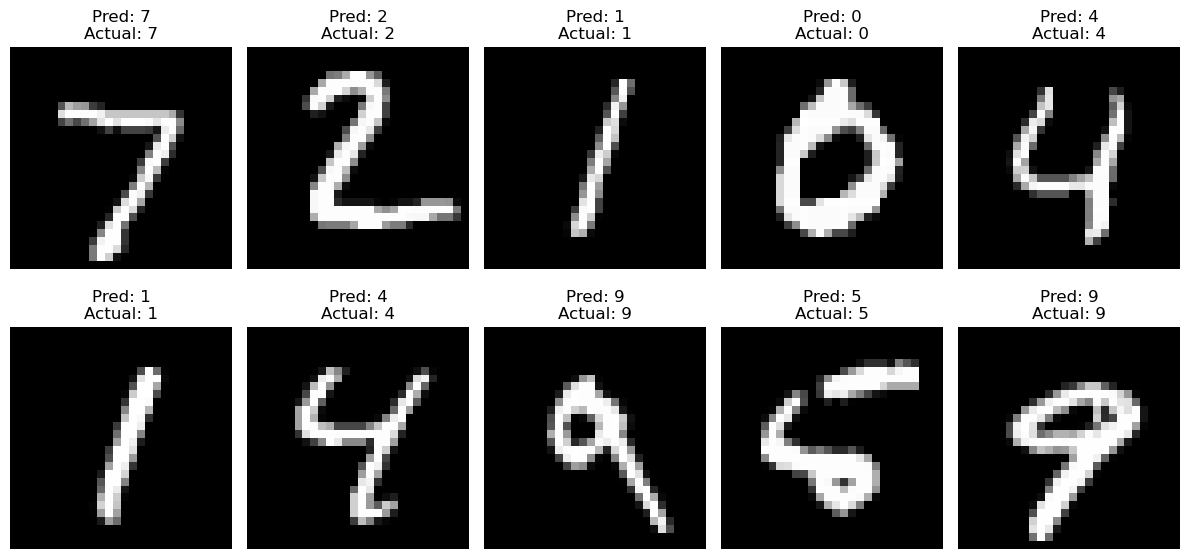

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)


# DISPLAY FIRST 10 TEST IMAGES

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Pred: {predicted_classes[i]}\nActual: {y_test[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

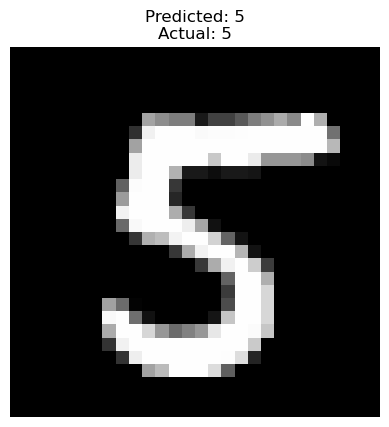

In [10]:
#Display a random image
import random

index = random.randint(
    0,
    len(X_test)-1
)

plt.imshow(
    X_test[index].reshape(28,28),
    cmap='gray'
)

plt.title(
    f"Predicted: {predicted_classes[index]}\nActual: {y_test[index]}"
)

plt.axis('off')
plt.show()